# Transport Coefficients

## Prelude
In this notebook we will calculate the viscosity of the Yukawa OCP.

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/YOCP/input_files/yocp_transport.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/YOCP/YOCP_Transport_NB.ipynb).


In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import os
plt.style.use('MSUstyle')

# Import sarkas
from sarkas.processes import Simulation, PostProcess 
# import observables
from sarkas.tools.observables import Thermodynamics, PressureTensor, HeatFlux, RadialDistributionFunction, VelocityAutoCorrelationFunction

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files', 'yocp_transport.yaml')

### Pre-processing

In [2]:
# pre = PreProcess(input_file_name)
# pre.setup(read_yaml=True)
# pre.run()

### Run Simulation

In [3]:
# sim = Simulation(input_file_name)
# sim.setup(read_yaml=True)
# sim.run()

## Post Processing

In [4]:
postproc = PostProcess(input_file_name, grab_last_step=True)
postproc.setup(read_yaml=True,)

no_slices = 1

## Thermodynamics

Let's take a look at the temperature and energy of the system

In [5]:
therm = Thermodynamics()
therm.setup(postproc.parameters, no_slices=no_slices)
therm.compute()



=========================== Thermodynamics ===========================
Data saved in: 
 SarkasSimulations/Al_transport/PostProcessing/Thermodynamics/Production/Al_transport.zarr

Time Series Data:
No. of blocks = 1
No. dumps per block = 10000
Total time per block: T = 3.3581e-11 [s] ~ 998 plasma periods
Time interval: dt = 3.3581e-15 [s] ~ 1.0e-01 plasma period



Thermodynamics calculation Time: 1 sec 595 msec 402 usec 500 nsec


In [6]:
import xarray as xr

therm_ds = xr.open_zarr(therm.zarr_store_path)
print(therm_ds)


<xarray.Dataset> Size: 2MB
Dimensions:    (species: 1, quantity: 6, time: 10000, slice: 1)
Coordinates:
  * quantity   (quantity) <U16 384B 'Total Energy' 'Temperature' ... 'Enthalpy'
  * slice      (slice) int64 8B 0
  * species    (species) <U2 8B 'Al'
  * time       (time) float64 80kB 0.0 3.358e-15 ... 3.357e-11 3.358e-11
Data variables:
    data       (species, quantity, time, slice) float64 480kB dask.array<chunksize=(1, 6, 10000, 1), meta=np.ndarray>
    mean_data  (species, quantity, time) float64 480kB dask.array<chunksize=(1, 6, 10000), meta=np.ndarray>
    std_data   (species, quantity, time) float64 480kB dask.array<chunksize=(1, 6, 10000), meta=np.ndarray>


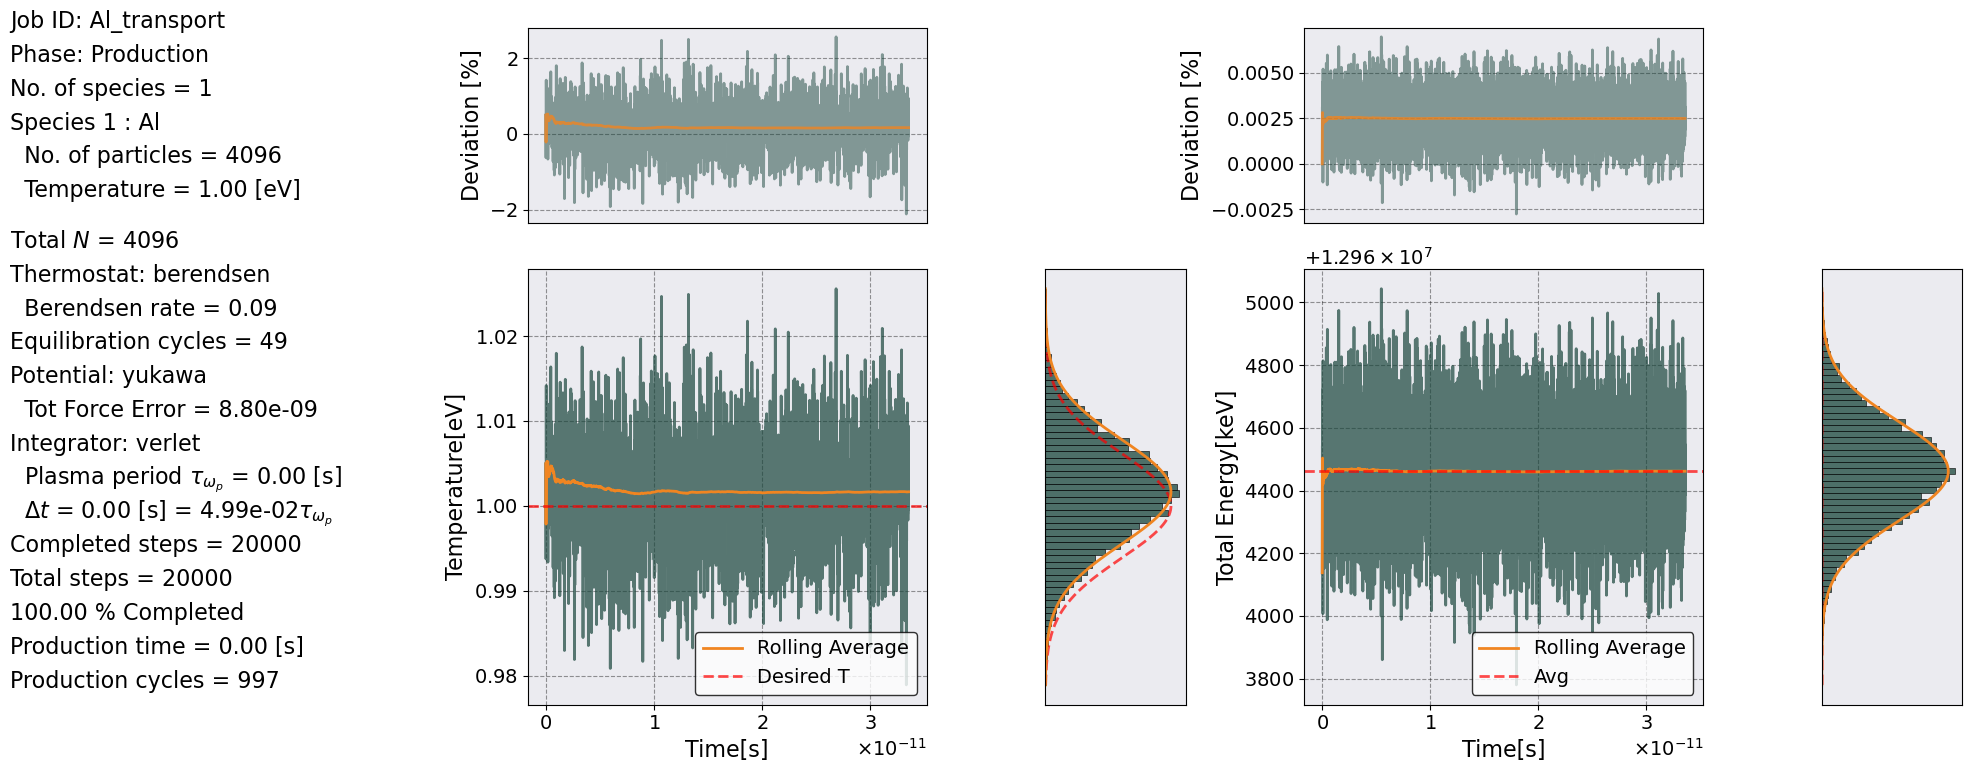

In [7]:
fig, T_axes, E_axes = therm.temp_energy_plot(
    postproc,          # pass the Process object for the info panel
    phase='production'
)

### Key Observations

#### Temperature

- **Temperature Behavior**:
  - During the production phase (bottom left plot), the temperature fluctuates around the desired value of 11.60 kK.
  - The moving average of the temperature (orange line) closely follows the desired temperature (red dashed line), indicating that the system maintained the desired temperature during the equilibration phase and carried this stability into the production phase.
  
- **Fluctuations**:
  - The temperature fluctuations are within an acceptable range, suggesting that the system is well-equilibrated and stable during the NVE production phase.

#### Energy

- **Total Energy Fluctuations**:
  - The total energy plot (bottom right) shows fluctuations around a mean value.
  - The moving average of the total energy (orange line) remains relatively constant, indicating energy conservation in the NVE ensemble.

- **Energy Distribution**:
  - The histogram of the energy values shows a roughly Gaussian distribution, typical for an equilibrated system in an NVE ensemble.
  - The standard deviation of the energy distribution is small, indicating stable energy fluctuations around the mean.

### System Stability and Equilibration

- **System Stability**:
  - Both the temperature and energy plots indicate that the system has reached a stable state after initial equilibration. The thermostat used in the $NVT$ equilibration phase successfully prepared the system for stable dynamics in the $NVE$ production phase.
  
- **Thermostat Efficiency**:
  - The Berendsen thermostat effectively maintained the temperature during the equilibration phase, allowing the system to transition smoothly into the $NVE$ production phase with stable temperature and energy fluctuations.

- **Fluctuation Analysis**:
  - The magnitude of temperature and energy fluctuations appears to be small, indicating a well-equilibrated system with minimal drift during the $NVE$ production phase.

### Conclusion

The provided plot shows that the MD simulation resulted in a stable and well-equilibrated system. The temperature and energy remained stable throughout the production phase, confirming that the system maintained the desired conditions set during the equilibration phase.

## Pair Distribution Function

The first observable to calculate is always the RDF. 

First, we initialize the RDF computation by creating an instance of the `RadialDistributionFunction` class. We then set up the RDF calculation parameters using the setup method and compute the RDF using the compute method.

In [8]:
rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters, no_slices=no_slices)
rdf.compute()




==================== Radial Distribution Function ====================
Data saved in: 
 SarkasSimulations/Al_transport/PostProcessing/RadialDistributionFunction/Production/Al_transport.zarr

Time Series Data:
No. of blocks = 1
No. dumps per block = 10000
Total time per block: T = 3.3581e-11 [s] ~ 998 plasma periods
Time interval: dt = 3.3581e-15 [s] ~ 1.0e-01 plasma period


Calculating RDF for slice: 100%|██████████| 1/1 [00:00<00:00, 855.63it/s]


Radial Distribution Function Calculation Time: 0 sec 40 msec 313 usec 750 nsec


After running the RDF computation, Sarkas provides a detailed summary of the calculation parameters and results.

Finally, we plot the computed RDF using the provided plotting functionality. We normalize the x-axis by the characteristic length scale $a_{ws}$ and label the axes appropriately.

In [9]:
rdf_ds = xr.open_zarr(rdf.zarr_store_path)

# Print info about the xarray dataset dims and coordinates
print(rdf_ds)

<xarray.Dataset> Size: 20kB
Dimensions:      (species_row: 1, species_col: 1, r: 500, slice: 1)
Coordinates:
  * r            (r) float64 4kB 9.479e-11 2.844e-10 ... 9.45e-08 9.469e-08
    ra           (r) float64 4kB dask.array<chunksize=(500,), meta=np.ndarray>
  * slice        (slice) int64 8B 0
  * species_col  (species_col) <U2 8B 'Al'
  * species_row  (species_row) <U2 8B 'Al'
Data variables:
    mean_rdf     (species_row, species_col, r) float64 4kB dask.array<chunksize=(1, 1, 500), meta=np.ndarray>
    rdf          (species_row, species_col, r, slice) float64 4kB dask.array<chunksize=(1, 1, 500, 1), meta=np.ndarray>
    std_rdf      (species_row, species_col, r) float64 4kB dask.array<chunksize=(1, 1, 500), meta=np.ndarray>


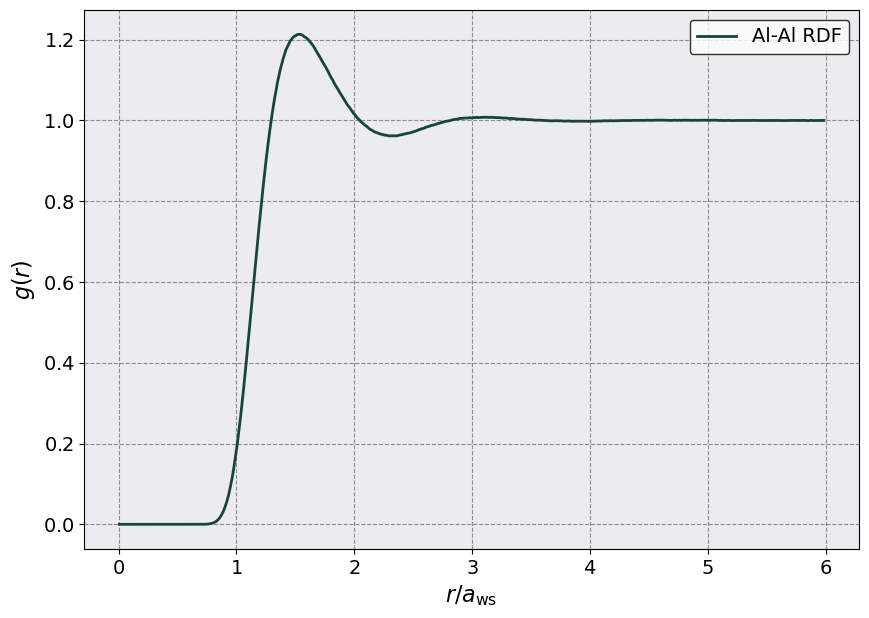

In [10]:
# Plot the RDF with error bars
fig, ax = plt.subplots()
rdf_ds["mean_rdf"].sel(species_row = "Al", species_col="Al").plot(
    x = 'ra',
    ax=ax,
    label="Al-Al RDF",
)
ax.set(xlabel=r'$r/a_{\rm ws}$', ylabel=r'$g(r)$', title="")
ax.legend()

The plot shows the radial distribution function $g(r)$ as a function of the normalized distance $r/a_{ws}$. This function describes how particle density varies as a function of distance from a reference particle, providing insights into the local structure of the system.

## Pressure Tensor

The viscosity is obtained from the autocorrelation function (ACF) of the Pressure Tensor $\overleftrightarrow{\mathcal P}$ whose elements are

\begin{equation}
\mathcal P_{\alpha\gamma}(t) = \frac{1}{V} \sum_{i}^{N} \left [ m_i v^{\alpha}_{i} v^{\gamma}_{i} -  \sum_{j > i} \frac{r_{ij}^{\alpha} r_{ij}^{\gamma} }{r_{ij}} \frac{d}{dr}\phi(r) \right ],
\end{equation}

where $r_{ij}^{\alpha}$ is the $\alpha$ component of the distance between particles $i$ and $j$. The first term is the kinetic term and the second term is the virial term, but it is often referred to as the potential contribution. The virial is calculated during the simulation phase and saved together with particles corrdinates. 

Let's calculate the Pressure tensor and the pressure $\mathcal P$.

In [19]:
pt = PressureTensor()
pt.setup(postproc.parameters, no_slices=no_slices)
pt.compute()

pt_ds = xr.open_zarr(pt.zarr_store_path)




========================== Pressure Tensor ===========================
Data saved in: 
 SarkasSimulations/Al_transport/PostProcessing/PressureTensor/Production/Al_transport.zarr

Time Series Data:
No. of blocks = 1
No. dumps per block = 10000
Total time per block: T = 3.3581e-11 [s] ~ 998 plasma periods
Time interval: dt = 3.3581e-15 [s] ~ 1.0e-01 plasma period



Calculating Pressure Tensor for slice : 100%|██████████| 1/1 [00:00<00:00, 993.20it/s]


Pressure Tensor calculation Time: 1 sec 372 msec 465 usec 500 nsec


In [20]:
# Display some info of the dataset
# display the dataset dimensions 
print(f"Dataset dimensions:\n {pt_ds.sizes}")
# display the dataset variables
print(f"Dataset variables: {pt_ds.data_vars}")
# Display the values for each dimension
print("\nDimension values:")
for dim in pt_ds.dims:
    vals = pt_ds[dim].values
    n = len(vals)
    print(f"  {dim}: {n} unique values")
    print(f"    {vals}")

Dataset dimensions:
 Frozen({'component': 6, 'species': 2, 'time': 10000, 'slice': 1})
Dataset variables: Data variables:
    mean_pressure  (species, time) float64 160kB dask.array<chunksize=(2, 10000), meta=np.ndarray>
    mean_tensor    (species, component, time) float64 960kB dask.array<chunksize=(2, 6, 10000), meta=np.ndarray>
    pressure       (species, time, slice) float64 160kB dask.array<chunksize=(2, 10000, 1), meta=np.ndarray>
    std_pressure   (species, time) float64 160kB dask.array<chunksize=(2, 10000), meta=np.ndarray>
    std_tensor     (species, component, time) float64 960kB dask.array<chunksize=(2, 6, 10000), meta=np.ndarray>
    tensor         (species, component, time, slice) float64 960kB dask.array<chunksize=(2, 6, 10000, 1), meta=np.ndarray>

Dimension values:
  component: 6 unique values
    ['XX' 'XY' 'XZ' 'YY' 'YZ' 'ZZ']
  species: 2 unique values
    ['Al' 'Total']
  time: 10000 unique values
    [0.00000000e+00 3.35811300e-15 6.71622600e-15 ... 3.35710557

As usual the data is saved in several dataframes. In this case we have 4 dataframes

* A dataframe for the values of each of the elements of the pressure tensor for each of the slices, `pt.dataframe_slices`
* A dataframe for the mean and std values of each of the elements of the pressure tensor, `pt.dataframe`
* A dataframe for the ACF of each pair $\langle \mathcal P_{\alpha\beta}(t)\mathcal P_{\mu\nu}(0) \rangle$ for each slice, `pt.dataframe_acf_slices`
* A dataframe for the mean and std of the ACF of each pair $\langle \mathcal P_{\alpha\beta}(t)\mathcal P_{\mu\nu}(0) \rangle$, `pt.dataframe_acf`

The above code snipper computed only the pressure tensor elements and not their autocorrelations. Let's look at `pt.dataframe` and its columns

There are 15 columns in this dataset; the time column, a `Mean` and `Std` column for scalar pressure $\mathcal P(t)$ `(Total, Pressure, Mean/Std)`, and `Mean` and `Std` column for elements of the tensor. Note that only the elements (`XY`,`XZ`, `YZ`) are calculated since the tensor is supposed to be symmetric in the isotropic case. 

Let's plot the Pressure as a function of time

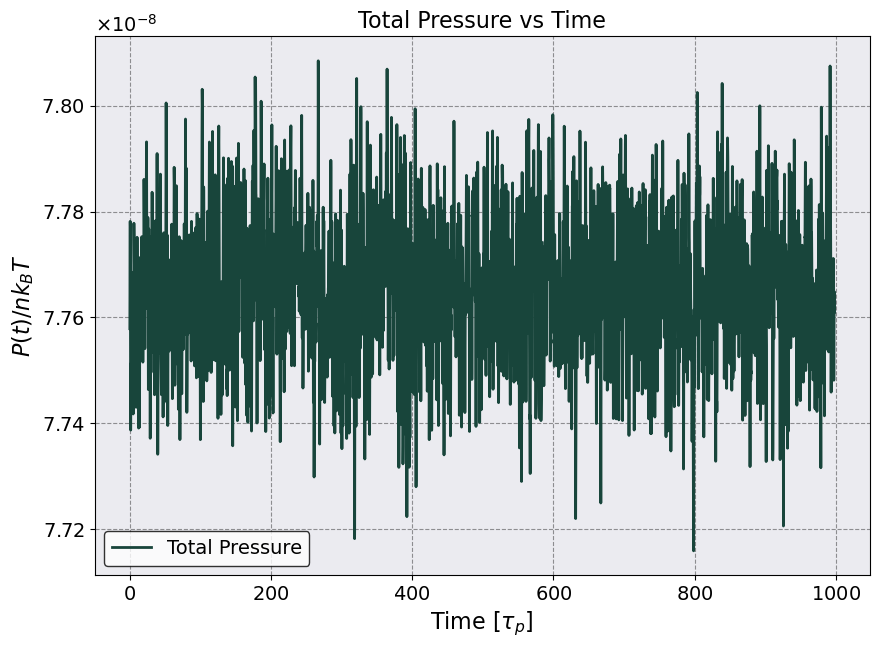

In [21]:
# Plot the total pressure
P_id = pt.total_num_density * therm.beta * pt.kB
pressure_scalar = pt_ds['pressure'].sel(species='Total').mean('slice').values
time_array = pt_ds['time'].values / pt.plasma_period

fig, ax = plt.subplots()
ax.plot(time_array, pressure_scalar / P_id, label='Total Pressure')
ax.set(xlabel=r'Time $[\tau_p]$', ylabel=r'$P(t)/nk_B T$', title='Total Pressure vs Time')
ax.legend()


This plot shows that the pressure is constant throughout the simulation. It would be nice to have some more information though. In fact we can make plots showing the deviation from the average pressure and a histogram of the pressure. The following code shows us how.

In [22]:
# from sarkas.tools.observables import make_gaussian_plot

In [23]:
# from sarkas.tools.observables import make_gaussian_plot
# fig, axes = make_gaussian_plot(
#     time = pt.dataframe[("Total", "Quantity", 'Time')]/t_wp,
#     data = pt.dataframe[("Total",'Pressure','Mean')]/p_id,
#     xlabel = 'Plasma periods',
#     ylabel = r"$ \beta P_{ex}(t)/n$"
# )

This figure is useful to understand the properties of our data. The main plot shows the (normalized) pressure as a function of time rescaled by the plasma period. The dashed red line indicates the mean of the time series and the orange line is the cumulative average. The top plot shows the standard deviation of our data as a function of time with the corresponding cumulative average. The plot on the right, finally, shows a histogram of the pressure data (green), while the orange line is Gaussian distribution whose mean and standard deviation are obtained from the pressure data.

Things to be understood from this plot is that the pressure is a stationary process, meaning that its mean and std do not change with time. In more technical term, the pressure is a stationary process if the data does not have a unit-root. While the plot is a good visual there are statistical tests to confirm the stationarity of time series data. These are the ADF and KPSS test. 

The code below runs these statistical tests and ouputs their results.

In [24]:
# from sarkas.tools.observables import check_stationarity

# check_stationarity(pt.dataframe[("Total", "Pressure", "Mean")]/p_id)

## Pressure from RDF

In order to check that our code are correct, let's verify some laws. 

The pressure of the system is calculated from $\mathcal P(t)= \frac1{3} {\rm Tr} \overleftrightarrow{\mathcal P}(t)$ and also from 

\begin{equation}
P = n k_BT - \frac{4\pi}{6} n^2 \int_0^{\infty} dr \, r^3 g(r) \frac{d\phi(r)}{dr} 
\end{equation}

where $g(r)= 1 + h(r)$ is the pair distribution function that we have already calculated. In YOCP case we can calculate the Hartree term and obtain

\begin{equation}
P = n k_BT + \frac{3}{2} n k_BT \frac{\Gamma}{\kappa^2} - \frac{4\pi}{6} n^2 \int_0^{\infty} dr \, r^3 h(r) \frac{d\phi(r)}{dr} 
\end{equation}

Let's now calculate the pressure from the integral of the RDF. This is obtained from the method `compute_from_rdf` of the `Thermodynamics` object. 

Looking at the documentation of this [method](../../api/tools_subpckg/Thermodynamics_methods/sarkas.tools.observables.Thermodynamics.compute_from_rdf.rst) we notice that it returns five values:
the Hartree and correlational terms between species $A$ and $B$ and the ideal pressure $n k_BT$. 

The total pressure is given from the sum of the three terms and should be equal to the 

$$ P = n k_BT + P_{\rm Hartree} + P_{\rm Corr} = {\operatorname {Mean} } \left \{ \mathcal P(t) \right \} $$

In [25]:
therm.beta_slices = np.array(therm.beta)
nkT, _, _, p_h, p_c = therm.compute_from_rdf(rdf, postproc.potential)
kappa = postproc.potential.a_ws / postproc.potential.screening_length
p_h_yocp = postproc.potential.coupling_constant * 1.5 / kappa**2
print(f"The ratio between the calculated Hartree term and the theoretical value is: {p_h[0]/nkT / p_h_yocp :.4e}")

P_rdf = nkT + p_h + p_c
P_trace = pressure_scalar.mean()

rel_diff = (P_rdf[0] - P_trace)*100/P_rdf[0] 
print(f"The relative difference between the integral of g(r) and the mean of the time series data is = {rel_diff:.2f} %")

The ratio between the calculated Hartree term and the theoretical value is: 9.9825e-01
The relative difference between the integral of g(r) and the mean of the time series data is = 0.02 %


It seems that we have done a good job! Let's move on and calculate the autocorrelation functions (ACFs). 
We can do this by calling the `compute_acf` method.

In [26]:
pt.compute_acf()


Calculating Pressure Tensor ACF for slice : 100%|██████████| 1/1 [00:00<00:00, 69.08it/s]


Pressure Tensor ACF calculation Time: 0 sec 131 msec 845 usec 375 nsec


In [36]:
pt_ds = xr.open_zarr(pt.zarr_store_path)
pt_ds["mean_acf_tensor"].component_row

<xarray.DataArray 'component_row' (component_row: 6)> Size: 48B
array(['XX', 'XY', 'XZ', 'YY', 'YZ', 'ZZ'], dtype='<U2')
Coordinates:
  * component_row  (component_row) <U2 48B 'XX' 'XY' 'XZ' 'YY' 'YZ' 'ZZ'

### Sum rule

Let's now check that we have calculated the ACF correctly. The equal time ACFs of the elements of $\overleftrightarrow{\mathcal P}(t)$ obey the following sum rules

$$
\mathcal J_{zzzz}(0) = \frac 13 \sum_{\alpha}\left \langle \mathcal P_{\alpha\alpha}(0)\mathcal P_{\alpha\alpha}(0) \right \rangle  =  \frac{n}{\beta^2} \left [ 3 + \frac{2\beta}{15} I_1 + \frac \beta5 I_2 \right ] ,
$$ 
$$
\mathcal J_{zzxx}(0) = \frac 16 \sum_{\alpha} \sum_{\beta\neq\alpha} \left \langle \mathcal P_{\alpha\alpha}(0)\mathcal P_{\beta\beta}(0) \right \rangle = \frac{n}{\beta^2} \left [ 1 - \frac{2\beta}{5} I_1 + \frac \beta{15} I_2 \right ] ,
$$ 
$$
\mathcal J_{xyxy}(0) = \frac 16 \sum_{\alpha}\sum_{\beta \neq \alpha} \left \langle \mathcal P_{\alpha\beta}(0)\mathcal P_{\alpha\beta}(0) \right \rangle = \frac{n}{\beta^2} \left [ 1 + \frac{4\beta}{15} I_1 + \frac \beta{15} I_2 \right ] ,
$$ 

where

$$ 
I_1 = 2\pi n \int dr \, r^3 g(r)  \frac{d\phi(r)}{dr}, \quad I_2 = 2\pi n \int dr\, r^3 g(r) \frac{d^2\phi(r)}{dr^2}.
$$

Notice that all three equal time ACF satisfy 

$$ \mathcal J_{zzzz}(0) - \mathcal J_{zzxx}(0) = 2 \mathcal J_{xyxy}(0) .$$

In [61]:
# Isotropy condition — select all off-diagonal, take diagonal of result matrix
off = ['XY','XZ','YZ']
acf0 = pt_ds['mean_acf_tensor'].sel(species='Total',
                             component_row=off, component_col=off).isel(lag=0)
J_xyxy_0 = float(acf0.values.diagonal().mean())
J_zzzz_0 = float(pt_ds['mean_acf_tensor'].sel(species='Total',
    component_row=['XX','YY','ZZ'], component_col=['XX','YY','ZZ']
    ).isel(lag=0).values.diagonal().mean())
J_zzxx_0 = float(pt_ds['mean_acf_tensor'].sel(species='Total',
    component_row='XX', component_col=['YY','ZZ']
    ).isel(lag=0).mean())


# The units of J's are [Density *  Energy]^2
condition = (J_zzzz_0 - J_zzxx_0) /(2.0 * J_xyxy_0)
msg = f'The isotropy condition : (J_zzzz_0 - J_zzxx_0 )/( 2*J_xyxy_0 ) = {condition:.4f}'
print(msg)

The isotropy condition : (J_zzzz_0 - J_zzxx_0 )/( 2*J_xyxy_0 ) = 0.9244


In [ ]:
# Plot the XYXY, XZXZ, YZYZ components of the ACF tensor
fig, ax = plt.subplots()
for comp in off:
    acf_comp = pt_ds['mean_acf_tensor'].sel(species='Total', component_row=comp, component_col=comp).values
    # Normalize by the zero-lag value
    acf_comp_norm = acf_comp/acf_comp[0]
    ax.plot(pt_ds['lag'].values/pt.plasma_period, acf_comp_norm, label=f'{comp}{comp}')

ax.set(xlabel=r'Lag $[\tau_p]$', ylabel=r'$P_{\alpha\beta}(t)$', title='ACF Tensor Components', xscale='log')
ax.legend()

Let's now verify the sum rules. These are calculated from the `pt.sum_rule` method which takes as inputs the inverse temperature $\beta$, the `RadialDistributionFunction` instance, and the `Potential` instance. 

In [ ]:
def sum_rule(self, beta, rdf, potential):
    r"""
    Calculate the sum rule integrals from the rdf.

    .. math::
        :nowrap:

        \begin{eqnarray}
            \sigma_{zzzz} & = &   \frac{n}{\beta^2} \left [ 3 +
            \frac{2\beta}{15} I^{(1)} + \frac{\beta}{5} I^{(2)} \right ] , \\
            \sigma_{zzxx} & =& \frac{n}{\beta^2} \left [ 1
            - \frac{2\beta}{5} I^{(1)} + \frac {\beta}{15} I^{(2)} \right ] , \\
            \sigma_{xyxy} & = & \frac{n}{\beta^2} \left [ 1 +
            \frac{4\beta}{15} I^{(2)} + \frac {\beta}{15} I^{(2)} \right ] ,
        \end{eqnarray}

    where :math:`I^{(k)} = \sum_{A} \sum_{B \geq A}I_{AB}^{(\rm {Hartree}, k)} + I_{AB}^{(\rm {Corr}, k)}`
    calculated from
    :meth:`sarkas.tools.observables.RadialDistributionFunction.compute_sum_rule_integrals`.

    Parameters
    ----------
    beta: float
        Inverse temperature factor. Grab it from :py:attr:`sarkas.tools.observables.Thermodynamics.beta`.

    rdf: sarkas.tools.observables.RadialDistributionFunction
        Radial Distribution function object.

    potential : :class:`sarkas.potentials.core.Potential`
        Potential object.

    Returns
    -------
    sigma_zzzz : float
        See above integral.

    sigma_zzxx : float
        See above integral.

    sigma_xyxy : float
        See above integral.
    """

    hartrees, corrs = rdf.compute_sum_rule_integrals(potential)
    # Eq. 2.3.43 -44 in Boon and Yip
    I_1 = hartrees[:, 1].sum() + corrs[:, 1].sum()
    I_2 = hartrees[:, 2].sum() + corrs[:, 2].sum()
    nkT = self.total_num_density / beta

    sigma_zzzz = 3.0 * nkT + 2.0 / 15.0 * I_1 + I_2 / 5.0
    sigma_zzxx = nkT - 2.0 / 5.0 * I_1 + I_2 / 15.0
    sigma_xyxy = nkT + 4.0 / 15.0 * I_1 + I_2 / 15.0

    return sigma_zzzz, sigma_zzxx, sigma_xyxy

In [ ]:
# Calculate the elastic constants from the integrals of g(r)
sigma_zzzz, sigma_zzxx, sigma_xyxy = sum_rule(pt, therm.beta_slices.mean(), rdf, postproc.potential)
print(f"{sigma_zzzz:.3e}, {sigma_zzxx:.3e}, {sigma_xyxy:.3e}")

In [ ]:
# Shear modulus
G_inf = J_xyxy_0*therm.beta_slices.mean()*pt.box_volume
K_inf = 1.0/3.0*(J_zzzz_0 + 2.0* J_zzxx_0)*therm.beta_slices.mean()*pt.box_volume

K_sr = (sigma_zzzz + 2.0*sigma_zzxx)/3.0

print("G_inf = {:.3e}, sum_rule = {:.3e}, ratio = {:.4f}".format( G_inf, sigma_xyxy, abs(sigma_xyxy) /G_inf) )
print("K_inf = {:.3e}, sum_rule = {:.3e}, ratio = {:.2e}".format( K_inf,  K_sr, K_sr /K_inf) )

In [ ]:
acf_xyxy = pt_ds['mean_acf_tensor'].sel(species='Total', component_row=off, component_col=off).values
acf_xyxy_0 = pt_ds['mean_acf_tensor'].sel(species='Total', component_row=off, component_col=off).isel(lag=0).values
acf_xyxy_norm = acf_xyxy/acf_xyxy_0[:, :, np.newaxis]
acf_xyxy_norm = acf_xyxy_norm.trace()/3.
acf_xyxy_norm.shape


In [ ]:
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
from sarkas.tools.fit_functions import rse

def fit_acf_power_series(t, a, b, c):
    # factorial2 = 2
    factorial4 = 24
    factorial6 = 720
    return 1.0 - 0.5 * a * t**2 - b/factorial4 * t**4 - c/factorial6 * t**6

def acf_fitting(t_range, acf):
    
    corr_times = 2.0 * cumulative_trapezoid(acf**2, x = t_range, axis = 0)  
    # Fit a power series to the short-time ACF behavior
    # ACF = 1 - a/2 t^2 - b t^4 - c t^6
    # Enfore that beta > 0, tauE > 0, tau0 > 0
    short_time_limit = 1.0 / 2# Fit up to 1/5 plasma cycles
    popt, pcov = curve_fit(fit_acf_power_series, 
                           t_range[t_range < short_time_limit], acf[t_range < short_time_limit], p0 = [1.0, 1.0, 1.0],
                           bounds= [ (0.0, 0.0, 0.0), (np.inf, np.inf, np.inf)]
                           )


    a, b, c = popt

    # d = beta * (tau0/tauE)**beta
    # a =  d/tau0^2
    # b = 3* d * (2 - beta + d)/tau0^4
    # c = 15*d*( 8 - 6*beta + beta**2 - 3 * d* beta + 6 d + d**2)/tau0**6
    # Solve the system to find tau0, tauE, and beta
    # Solve for d, tau0, beta using fsolve
    from scipy.optimize import fsolve

    def equations(vars):
        tau0, tauE, beta = vars
        d = beta * (tau0/tauE)**beta
        eq1 = a - d / tau0**2
        eq2 = b - 3 * d * (2 - beta + d) / tau0**4
        eq3 = c - 15 * d * (8 - 6*beta + beta**2 - 3*d*beta + 6*d + d**2) / tau0**6
        return [eq1, eq2, eq3]

    tau0_val, tauE_val, beta_val = fsolve(equations, (1.0, 1.0, 1.0))

    print("Power series fit parameters: M2 = {:.4e}, M4 = {:.4e}, M6 = {:.4e}".format(a, b, c))
    print("Initial guesses from power series fit: tau0 = {:.4e}, tauE = {:.4e}, beta = {:.4e}".format(tau0_val, tauE_val, beta_val))

    # Fit the RSE using the obtained parameters as initial guess
    popt_rse, pcov_rse = curve_fit(
        rse,
        t_range,
        acf,
        p0 = [tau0_val, tauE_val, beta_val],
        bounds= [ (0.0, 0.0, 0.0), (np.inf, np.inf, np.inf)]
    )
    return popt, popt_rse, short_time_limit, corr_times

def plot_acf_and_rse_fit(t_range, acf, popt, popt_rse, short_time_limit):
    """Plot the ACF along with the power series fit and RSE fit."""
    
    corr_time = max(popt_rse[1], popt_rse[0])
    za_err = (1 - acf) * np.sqrt(2 * corr_time/t_range[-1])

    fig, ax = plt.subplots(1,1)
    ax.plot(t_range, acf, label = 'ACF')
    ax.fill_between(
        t_range,
        acf - za_err,
        acf + za_err,
        alpha=0.3
    )
    ax.plot(t_range[t_range < short_time_limit], fit_acf_power_series(t_range[t_range < short_time_limit], *popt), label = 'Power Series Fit')
    ax.plot(t_range, rse(t_range, tau0 = popt_rse[0], tauE = popt_rse[1], beta = popt_rse[2]), label = 'RSE Fit')

    ax.set(xlabel = r'Lag $[\tau_p]$', 
        ylabel = r'Normalized Heat Flux ACF',
        xscale = 'symlog')
    ax.legend()
    # Print fitted parameters
    print("Fitted parameters from Power Series:")
    print("M_2 = {:.4e}, M_4 = {:.4e}, M_6 = {:.4e}".format(popt[0], popt[1], popt[2]))
    print("Fitted parameters from RSE:")
    print("tau0 = {:.4e}, tauE = {:.4e}, beta = {:.4e}".format(popt_rse[0], popt_rse[1], popt_rse[2]))


t_range = pt_ds['lag'].values/pt.plasma_period

popt, popt_rse, short_time_limit, corr_times = acf_fitting(t_range, acf_xyxy_norm)
fig = plot_acf_and_rse_fit(t_range, acf_xyxy_norm, popt, popt_rse, short_time_limit)


In [ ]:
from sarkas.tools.observables import UNITS

# Cumulative integral of the ACF and its RSE fit
eta_acf = cumulative_trapezoid(acf_xyxy_norm, x = t_range, axis = 0)
eta_rse = cumulative_trapezoid(rse(t_range, tau0 = popt_rse[0], tauE = popt_rse[1], beta = popt_rse[2]), x = t_range, axis = 0)
fig, ax = plt.subplots(1,1)
ax.plot(t_range[1:], eta_acf, label = 'Cumulative eta ACF')
ax.plot(t_range[1:], eta_rse, label = 'Cumulative eta RSE Fit')
ax.set(xlabel = r'Lag $[\tau_p]$', 
       ylabel = r'Cumulative Integral of Pressure Tensor ACF',
       xscale = 'symlog')
ax.legend()

# Viscosity
eta_tc = eta_rse[-1] 

units_dict = UNITS[1]
print("Viscosity from ACF = {:.4e} {}".format( eta_tc, units_dict['Viscosity']) )

In [ ]:
from scipy.integrate import cumulative_trapezoid

corr_times = 2.0 * cumulative_trapezoid(acf_xyxy_norm**2, x = t_range, axis = 0)
fig, ax = plt.subplots(1,1)
ax.plot(t_range[:-1], corr_times, label = 'XY')
ax.legend()
ax.set(xlabel = r'Lag $[\tau_p]$', ylabel = 'Correlation time', xscale = 'symlog', ylim = (0, 2))

In [ ]:
acf_df = pt.calc_better_acf_data(plasma_periods_shift = 1)
acf_df.info()

In [ ]:
acf_df

In [ ]:
# Plot
acf_0 = acf_df["Stress ACF Mean"].iloc[0]
fig, ax = plt.subplots(1,1)
ax.plot(acf_df["Time"]/t_wp, acf_df["Stress ACF Mean"]/acf_0)
ax.fill_between(acf_df["Time"]/t_wp, 
                acf_df["Stress ACF Mean"]/acf_0 - acf_df["Stress ACF Std"]/acf_0,
               acf_df["Stress ACF Mean"]/acf_0 + acf_df["Stress ACF Std"]/acf_0,
               alpha = 0.3)
ax.set(xscale= 'symlog', ylim = (-0.1, 1.1))

## Viscosity

The shear viscosity is calculated from the Green-Kubo relation

\begin{equation}
\eta = \frac{\beta V}{3} \sum_{\alpha} \sum_{\gamma \neq \alpha} \int_0^{\infty} dt \, \left \langle \delta\mathcal P_{\alpha\gamma}(t) \delta \mathcal P_{\alpha\gamma}(0) \right \rangle,
\end{equation}

where $\beta = 1/k_B T$, $\alpha,\gamma = {x, y, z}$ and $\delta \mathcal P_{\alpha\gamma}(t) = \mathcal P_{\alpha\gamma}(t) - \left \langle \mathcal P_{\alpha\gamma} \right \rangle_t$.

The bulk viscosity is given by a similar relation

\begin{equation}
\eta_V = \beta V \int_0^{\infty}dt \,  \left \langle \delta \mathcal P(t) \delta \mathcal P(0) \right \rangle,
\end{equation}

where $\delta \mathcal P(t) = \mathcal P(t) - \left \langle \mathcal P  \right \rangle_t$ is the fluctuation of the scalar pressure.

In [ ]:
from scipy.integrate import cumulative_trapezoid

eta_t = therm.beta_slices.mean() * pt.box_volume * cumulative_trapezoid(acf_df.iloc[:,1], x = acf_df.iloc[:, 0])

### Einstein frequency

The formula is 

\begin{equation}
\omega_E^2 = \frac{4\pi n}{3 m}\left [ 2\int_0^{\infty} dr \, r g(r) \frac{d\phi(r)}{dr}  + \int_0^{\infty} dr \, r^2 g(r) \frac{d^2\phi(r)}{dr^2} \right ] 
\end{equation}

In [ ]:
r = rdf.ra_values * rdf.a_ws
r[0] = 1e-40
_, du_dr, d2u_dr2 = postproc.potential.potential_derivatives(r, postproc.potential.matrix[0,0])
gr = rdf.dataframe[("Al-Al RDF", "Mean")].values
omega_E = np.sqrt(4.0 * np.pi * rdf.total_num_density/ (3 * rdf.species_masses[0]) * np.trapezoid( 2 * r * gr * du_dr  + r**2 * gr * d2u_dr2, x = r))
omega_E/rdf.total_plasma_frequency, np.exp(-0.2 * kappa**1.62)/ np.sqrt(3)

In [ ]:
def murillo_yvm(kappa, gamma):
    gamma_m_k = 171.8 + 82.8*(np.exp(0.565*kappa**1.38) - 1)
    eta_E = 0.0051 * gamma_m_k/gamma + 0.374 * gamma/gamma_m_k + 0.022
    eta = eta_E * omega_E/rdf.total_plasma_frequency # np.exp(-0.2 * kappa**1.62)/np.sqrt(3)
    return eta

def murillo_iyvm(kappa, gamma):
    gamma_m_k = 171.8 + 82.8*(np.exp(0.565*kappa**1.38) - 1)
    Ak = 1.45e-4 - 1.04e-4*kappa +3.69e-5*kappa**2
    ak = 1.78+0.13*kappa - 0.062*kappa**2
    Bk = 0.3+0.86*kappa - 0.69*kappa**2 +0.138 * kappa**3
    bk = 1.63 - 0.325 * kappa + 0.24*kappa**2
    Ck = 0.015 + 0.048 * kappa**0.754
    
    eta_E = Ak * (gamma_m_k/gamma)**ak + Bk * (gamma/gamma_m_k)**bk + Ck
    eta = eta_E * omega_E/rdf.total_plasma_frequency # np.exp(-0.2 * kappa**1.62)/np.sqrt(3)
    return eta

In [ ]:
time_rescaled = acf_df.iloc[1:,0] / pt.plasma_period
eta_rescale_const = pt.total_plasma_frequency * pt.a_ws**2 * pt.species_masses[0] * pt.total_num_density

kappa = pt.a_ws/postproc.potential.screening_length

fig, ax = plt.subplots(1,1)
ax.plot(time_rescaled,
        eta_t/eta_rescale_const,
       label = r'$\eta$')
eta_yvm = murillo_yvm(kappa, postproc.potential.coupling_constant)
eta_iyvm = murillo_iyvm(kappa, postproc.potential.coupling_constant)
ax.axhline(eta_yvm, ls = '--', c = 'r', label = "YVM")
ax.axhline(eta_iyvm, ls = ':', c = 'b', label = "IYVM")
ax.legend()
ax.set(xlabel = r'Plasma periods lag',
      ylabel = r"Shear viscosity $\eta$",
      xscale=  'log',
        ylim = (0, 0.05)
      )


## Thermal Conductivity

In [ ]:
from sarkas.tools.observables import HeatFlux
from sarkas.tools.transport import ThermalConductivity

In [ ]:
ht = HeatFlux()
ht.setup(postproc.parameters)
ht.compute(calculate_acf=True)

In [ ]:
ht.filename_hdf_slices

In [ ]:
ht.plot(scaling = t_wp,
        y = [("Heat Flux", 'Al', 'X', "Mean"),
             ("Heat Flux", 'Al', 'Y', "Mean"), 
             ("Heat Flux", 'Al', 'Z', "Mean")
            ],
       xlabel = 'Plasma Periods',
       ylabel = 'Heat Flux [erg cm/s]',
)

In [ ]:
ht.dataframce_acf.info()

In [ ]:
column = ('Heat Flux ACF', 'Al-Al', 'Total', 'Mean')
avg = ht.dataframe_acf[column]
acfs = avg/avg.iloc[0]
corr_times = 2.0 * cumulative_trapezoid(acfs**2, x = ht.dataframe_acf.iloc[:,0] / ht.plasma_period, axis = 0)
fig, ax = plt.subplots(1,1)
ax.plot(ht.dataframe_acf.iloc[:-1,0]/ht.plasma_period,corr_times, label = 'Heat Flux')
ax.legend()
ax.set(xlabel = 'Plasma Periods', ylabel = 'Correlation time', xscale = 'symlog', ylim = (0, 2))

In [ ]:
acf_df = ht.calc_better_acf_data(plasma_periods_shift = 10)
display(acf_df.info())
acf_df

In [ ]:
# Plot
acf_0 = acf_df["Heat Flux ACF Mean"].iloc[0]
fig, ax = plt.subplots(1,1)
ax.plot(acf_df["Time"]/t_wp, acf_df["Heat Flux ACF Mean"]/acf_0)
ax.fill_between(acf_df["Time"]/t_wp, 
                acf_df["Heat Flux ACF Mean"]/acf_0 - acf_df["Heat Flux ACF Std"]/acf_0,
               acf_df["Heat Flux ACF Mean"]/acf_0 + acf_df["Heat Flux ACF Std"]/acf_0,
               alpha = 0.3)
ax.set(xscale= 'symlog', ylim = (-0.1, 1.1))

## Thermal Conductivity

The thermal conductivity $\kappa_t$ is calculated from the Green-Kubo formula

\begin{equation}
    \kappa_t = \frac{1}{3Vk_BT^2} \int_0^{t} d\tau \langle \mathbf {J}_{Q}(0) \cdot \mathbf {J}_{Q}(\tau) \rangle,
\end{equation}

Note that the 3 in the denominator is already accounted for in the calculation of the ACF. 

In [ ]:
kappa_t = therm.beta_slices.mean()**2 * ht.kB / ht.box_volume * cumulative_trapezoid(acf_df.iloc[:,1], x = acf_df.iloc[:, 0])

fig, ax = plt.subplots(1,1)
ax.plot(acf_df.iloc[1:,0]/t_wp, kappa_t, label = r'$\kappa$ from ACF')
ax.set(xscale= 'log', ylim = (0, None), 
       xlabel = 'Plasma Periods',
      ylabel = r'Thermal Conductivity $\kappa$ [erg/(cm s K)]'
      )

In [ ]:
thc = ThermalConductivity()
thc.setup(postproc.parameters, ht, therm)
thc.compute(ht)

In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(thc.dataframe.iloc[:,0]/t_wp, thc.dataframe.iloc[:,1], label = r'$\kappa$ from THC class')
ax.set(xscale= 'log', ylim = (0, None), 
       xlabel = 'Plasma Periods',
      ylabel = r'Thermal Conductivity $\kappa$ [erg/(cm s K)]'
      )